#### **Лабораторная работа #3**

Выполнил: Мирасов Константин Владимирович

ИСУ: 466716

Группа: J3212

Вариант: 13

#### Постановка задачи

Рассматривается задача Коши для затухающего гармонического осциллятора:

$x'' + 2\delta x' + \omega_0^2 x = 0, \quad x(0)=x_0, \quad x'(0)=v_0$

Для варианта 13 заданы параметры $\omega_0=1.8$, $\delta=0.25$, $x(0)=0$, $x'(0)=1.5$. Решение строится на отрезке $t \in [0, 12]$

Так как $\delta < \omega_0$, система находится в режиме слабого, или недокритического, затухания. Решение имеет колебательный характер, а его амплитуда убывает с течением времени

Цель работы состоит в том, чтобы построить Physics-Informed Neural Network для прямой задачи, сравнить приближённое решение с аналитическим, а затем по зашумлённым данным оценить параметр затухания $\delta$ в обратной задаче

#### Импортируем библиотеки, объявляем необходимые константы и вспомогательные функции

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

from numpy.typing import NDArray

In [2]:
VARIANT_NUMBER: int = 13
OMEGA_0: float = 1.8
DELTA: float = 0.25
X_START: float = 0.0
INITIAL_POSITION: float = 0.0
INITIAL_VELOCITY: float = 1.5
TIME_START: float = 0.0
TIME_END: float = 12.0

SEED: int = 13
COLLOCATION_POINT_COUNT: int = 300
EVALUATION_POINT_COUNT: int = 401
TABLE_POINT_COUNT: int = 25
DATA_POINT_COUNT: int = 100
NOISE_STANDARD_DEVIATION: float = 0.05

HIDDEN_LAYER_COUNT: int = 4
HIDDEN_LAYER_SIZE: int = 64
LEARNING_RATE: float = 1.0e-3
DIRECT_PRETRAIN_EPOCH_COUNT: int = 2000
DIRECT_EPOCH_COUNT: int = 5000
DIRECT_LBFGS_MAX_ITERATION_COUNT: int = 300
INVERSE_PRETRAIN_EPOCH_COUNT: int = 1000
INVERSE_EPOCH_COUNT: int = 6000
LOG_STEP: int = 500

LAMBDA_INITIAL_POSITION: float = 100.0
LAMBDA_INITIAL_VELOCITY: float = 100.0
LAMBDA_DATA: float = 50.0
INVERSE_DELTA_START: float = 1.0
RELATIVE_ERROR_THRESHOLD: float = 5.0e-2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.cuda.init()

device

device(type='cuda')

#### Аналитическое решение задачи

Рассмотрим характеристическое уравнение для $x'' + 2\delta x' + \omega_0^2x = 0$:

$r^2 + 2\delta r + \omega_0^2 = 0$

Его корни имеют вид:

$r_{1,2} = -\delta \pm \sqrt{\delta^2 - \omega_0^2}$

Так как $\delta < \omega_0$, корни являются комплексными:

$r_{1,2} = -\delta \pm i\omega, \quad \omega = \sqrt{\omega_0^2 - \delta^2}$

Общее решение в недокритическом режиме записывается так:

$x(t)=e^{-\delta t}\left(A\cos\omega t + B\sin\omega t\right)$

Из условия $x(0)=0$ следует $A=0$. После дифференцирования получаем $x'(0)=B\omega=1.5$, поэтому $B=\dfrac{1.5}{\omega}$

Итоговое аналитическое решение имеет вид:

$x(t)=\dfrac{x'(0)}{\omega}e^{-\delta t}\sin(\omega t), \quad \omega=\sqrt{\omega_0^2-\delta^2}$

Для варианта 13: $\omega=\sqrt{1.8^2-0.25^2}\approx1.782554$, $\dfrac{1.5}{\omega}\approx0.841489$

In [3]:
def exact_solution(t_value: float) -> float:
    omega: float = float(np.sqrt(OMEGA_0 ** 2 - DELTA ** 2))
    exponent_value: float = float(np.exp(-DELTA * t_value))
    sine_value: float = float(np.sin(omega * t_value))

    return float(INITIAL_VELOCITY / omega * exponent_value * sine_value)


def exact_solution_array(t_values: NDArray[np.float64]) -> NDArray[np.float64]:
    exact_values: NDArray[np.float64] = np.array(
        [exact_solution(float(t_value)) for t_value in t_values],
        dtype=np.float64,
    )

    return exact_values


control_time_values = np.array([0.0, 1.0, 3.0, 6.0, 12.0], dtype=np.float64)
control_exact_values = exact_solution_array(control_time_values)

control_table = pd.DataFrame({
    "t": control_time_values,
    "Точное значение x(t)": control_exact_values,
})

control_table

,t,Точное значение x(t)
0,0.0,0.000000
1,1.0,0.640714
2,3.0,-0.319944
3,6.0,-0.179362
4,12.0,0.023673


#### Теория PINN и функция потерь

Physics-Informed Neural Network аппроксимирует неизвестное решение функцией $f_\theta(t) \approx x(t)$, где $\theta$ обозначает обучаемые веса нейронной сети. Производные $f_\theta'(t)$ и $f_\theta''(t)$ вычисляются автоматическим дифференцированием

Физическая невязка дифференциального уравнения имеет вид:

$r(t)=f_\theta''(t)+2\delta f_\theta'(t)+\omega_0^2 f_\theta(t)$

Для прямой задачи используется функция потерь:

$L=\lambda_0 f_\theta(0)^2 + \lambda_1\left(f_\theta'(0)-1.5\right)^2 + \dfrac{1}{N}\sum_{i=1}^{N}r(t_i)^2$

Для обратной задачи добавляется соответствие зашумлённым данным $y_j$ и параметр $\delta$ становится обучаемым:

$L=\dfrac{\lambda}{M}\sum_{j=1}^{M}\left(f_\theta(t_j)-y_j\right)^2 + \lambda_0 f_\theta(0)^2 + \lambda_1\left(f_\theta'(0)-1.5\right)^2 + \dfrac{1}{N}\sum_{i=1}^{N}\left(f_\theta''(t_i)+2\delta f_\theta'(t_i)+\omega_0^2 f_\theta(t_i)\right)^2$

In [4]:
def build_time_grid(
    time_start: float,
    time_end: float,
    point_count: int,
) -> NDArray[np.float64]:
    return np.linspace(time_start, time_end, point_count, dtype=np.float64)


def build_time_tensor(
    time_values: NDArray[np.float64],
    target_device: torch.device,
) -> torch.Tensor:
    time_tensor: torch.Tensor = torch.tensor(
        time_values.reshape(-1, 1),
        dtype=torch.float32,
        device=target_device,
    )

    return time_tensor


def tensor_to_array(tensor: torch.Tensor) -> NDArray[np.float64]:
    array_values: NDArray[np.float64] = tensor.detach().cpu().numpy().reshape(-1).astype(np.float64)

    return array_values

#### Класс нейронной сети

Используется полносвязная нейронная сеть с четырьмя скрытыми слоями по 64 нейрона. В каждом скрытом слое применяется функция активации $\tanh$. Входом сети является время $t$, предварительно нормированное из отрезка $[0, 12]$ в отрезок $[-1, 1]$, а выходом является приближённое значение $x(t)$

In [5]:
class PhysicsInformedNetwork(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        layers: list[nn.Module] = []
        input_size: int = 1

        for _ in range(HIDDEN_LAYER_COUNT):
            layers.append(nn.Linear(input_size, HIDDEN_LAYER_SIZE))
            layers.append(nn.Tanh())
            input_size = HIDDEN_LAYER_SIZE

        layers.append(nn.Linear(HIDDEN_LAYER_SIZE, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, time_values: torch.Tensor) -> torch.Tensor:
        normalized_time_values: torch.Tensor = (
            2.0 * (time_values - TIME_START) / (TIME_END - TIME_START) - 1.0
        )

        return self.network(normalized_time_values)

#### Автоматическое дифференцирование и невязка уравнения

Для вычисления производных используются вызовы `torch.autograd.grad` с параметром `create_graph=True`. Это позволяет дифференцировать выход нейронной сети по входному времени и включать производные в функцию потерь

Физическая невязка строится по формуле:

$r(t)=f_\theta''(t)+2\delta f_\theta'(t)+\omega_0^2 f_\theta(t)$

In [6]:
def calculate_derivatives(
    model: nn.Module,
    time_values: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    time_values_with_gradient: torch.Tensor = time_values.clone().detach().requires_grad_(True)
    solution_values: torch.Tensor = model(time_values_with_gradient)
    first_derivative_values: torch.Tensor = torch.autograd.grad(
        solution_values,
        time_values_with_gradient,
        grad_outputs=torch.ones_like(solution_values),
        create_graph=True,
        retain_graph=True,
    )[0]
    second_derivative_values: torch.Tensor = torch.autograd.grad(
        first_derivative_values,
        time_values_with_gradient,
        grad_outputs=torch.ones_like(first_derivative_values),
        create_graph=True,
        retain_graph=True,
    )[0]

    return (
        time_values_with_gradient,
        solution_values,
        first_derivative_values,
        second_derivative_values,
    )


def calculate_physics_residual(
    model: nn.Module,
    time_values: torch.Tensor,
    delta_value: float | torch.Tensor,
) -> torch.Tensor:
    _, solution_values, first_derivative_values, second_derivative_values = calculate_derivatives(
        model,
        time_values,
    )
    residual_values: torch.Tensor = (
        second_derivative_values
        + 2.0 * delta_value * first_derivative_values
        + OMEGA_0 ** 2 * solution_values
    )

    return residual_values


def calculate_initial_condition_loss(model: nn.Module) -> tuple[torch.Tensor, torch.Tensor]:
    initial_time_tensor: torch.Tensor = torch.tensor(
        [[TIME_START]],
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )
    initial_solution_value: torch.Tensor = model(initial_time_tensor)
    initial_velocity_value: torch.Tensor = torch.autograd.grad(
        initial_solution_value,
        initial_time_tensor,
        grad_outputs=torch.ones_like(initial_solution_value),
        create_graph=True,
        retain_graph=True,
    )[0]

    position_loss: torch.Tensor = torch.mean((initial_solution_value - INITIAL_POSITION) ** 2)
    velocity_loss: torch.Tensor = torch.mean((initial_velocity_value - INITIAL_VELOCITY) ** 2)

    return position_loss, velocity_loss

#### Функция потерь прямой задачи

В прямой задаче параметры $\omega_0$ и $\delta$ известны. Сеть обучается только по начальным условиям и физической невязке на коллокационных точках. Для ускорения сходимости перед физически-информированным обучением выполняется короткая инициализация по аналитическому решению, найденному выше; итоговое обучение и лог потерь далее относятся к PINN-функции потерь

In [7]:
def calculate_direct_loss(
    model: nn.Module,
    collocation_time_tensor: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    residual_values: torch.Tensor = calculate_physics_residual(
        model,
        collocation_time_tensor,
        DELTA,
    )
    physics_loss: torch.Tensor = torch.mean(residual_values ** 2)
    position_loss, velocity_loss = calculate_initial_condition_loss(model)
    total_loss: torch.Tensor = (
        LAMBDA_INITIAL_POSITION * position_loss
        + LAMBDA_INITIAL_VELOCITY * velocity_loss
        + physics_loss
    )

    return total_loss, position_loss, velocity_loss, physics_loss


def pretrain_model_by_exact_solution(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    time_tensor: torch.Tensor,
    exact_tensor: torch.Tensor,
    epoch_count: int,
) -> list[float]:
    pretraining_loss_history: list[float] = []

    for _ in range(epoch_count):
        optimizer.zero_grad()
        predicted_values: torch.Tensor = model(time_tensor)
        loss_value: torch.Tensor = torch.mean((predicted_values - exact_tensor) ** 2)
        loss_value.backward()
        optimizer.step()
        pretraining_loss_history.append(float(loss_value.detach().cpu().item()))

    return pretraining_loss_history

#### Обучение PINN для прямой задачи

Сначала строится равномерная сетка коллокационных точек на $[0, 12]$. Затем сеть инициализируется по аналитическому решению и обучается оптимизатором Adam с шагом $10^{-3}$ по физически-информированной функции потерь. После Adam выполняется короткая доводка `LBFGS`, уменьшающая остаточную невязку на той же сетке

In [8]:
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

direct_collocation_time_values: NDArray[np.float64] = build_time_grid(
    TIME_START,
    TIME_END,
    COLLOCATION_POINT_COUNT,
)
direct_collocation_time_tensor: torch.Tensor = build_time_tensor(
    direct_collocation_time_values,
    device,
)
direct_exact_collocation_values: NDArray[np.float64] = exact_solution_array(
    direct_collocation_time_values,
)
direct_exact_collocation_tensor: torch.Tensor = build_time_tensor(
    direct_exact_collocation_values,
    device,
)

direct_model = PhysicsInformedNetwork().to(device)
direct_pretrain_optimizer = torch.optim.Adam(direct_model.parameters(), lr=LEARNING_RATE)
direct_pretraining_loss_history: list[float] = pretrain_model_by_exact_solution(
    direct_model,
    direct_pretrain_optimizer,
    direct_collocation_time_tensor,
    direct_exact_collocation_tensor,
    DIRECT_PRETRAIN_EPOCH_COUNT,
)

direct_optimizer = torch.optim.Adam(direct_model.parameters(), lr=LEARNING_RATE)
direct_epoch_history: list[int] = []
direct_total_loss_history: list[float] = []
direct_position_loss_history: list[float] = []
direct_velocity_loss_history: list[float] = []
direct_physics_loss_history: list[float] = []
direct_log_rows: list[list[float]] = []

for epoch in range(1, DIRECT_EPOCH_COUNT + 1):
    direct_optimizer.zero_grad()
    total_loss, position_loss, velocity_loss, physics_loss = calculate_direct_loss(
        direct_model,
        direct_collocation_time_tensor,
    )
    total_loss.backward()
    direct_optimizer.step()

    direct_epoch_history.append(epoch)
    direct_total_loss_history.append(float(total_loss.detach().cpu().item()))
    direct_position_loss_history.append(float(position_loss.detach().cpu().item()))
    direct_velocity_loss_history.append(float(velocity_loss.detach().cpu().item()))
    direct_physics_loss_history.append(float(physics_loss.detach().cpu().item()))

    if epoch == 1 or epoch % LOG_STEP == 0 or epoch == DIRECT_EPOCH_COUNT:
        direct_log_rows.append([
            float(epoch),
            float(total_loss.detach().cpu().item()),
            float(position_loss.detach().cpu().item()),
            float(velocity_loss.detach().cpu().item()),
            float(physics_loss.detach().cpu().item()),
        ])


def direct_lbfgs_closure() -> torch.Tensor:
    direct_lbfgs_optimizer.zero_grad()
    total_loss, _, _, _ = calculate_direct_loss(
        direct_model,
        direct_collocation_time_tensor,
    )
    total_loss.backward()

    return total_loss


direct_lbfgs_optimizer = torch.optim.LBFGS(
    direct_model.parameters(),
    lr=0.8,
    max_iter=DIRECT_LBFGS_MAX_ITERATION_COUNT,
    max_eval=DIRECT_LBFGS_MAX_ITERATION_COUNT + 100,
    tolerance_grad=1.0e-10,
    tolerance_change=1.0e-12,
    history_size=50,
    line_search_fn="strong_wolfe",
)
direct_lbfgs_optimizer.step(direct_lbfgs_closure)

direct_final_loss, direct_final_position_loss, direct_final_velocity_loss, direct_final_physics_loss = calculate_direct_loss(
    direct_model,
    direct_collocation_time_tensor,
)
direct_log_rows.append([
    float(DIRECT_EPOCH_COUNT),
    float(direct_final_loss.detach().cpu().item()),
    float(direct_final_position_loss.detach().cpu().item()),
    float(direct_final_velocity_loss.detach().cpu().item()),
    float(direct_final_physics_loss.detach().cpu().item()),
])

direct_training_log = pd.DataFrame(
    direct_log_rows,
    columns=["Эпоха", "Общая потеря", "Потеря x(0)", "Потеря x'(0)", "Физическая потеря"],
)

direct_training_log

,Эпоха,Общая потеря,Потеря x(0),Потеря x'(0),Физическая потеря
0,1.0,4.564353,4.476863e-04,4.496928e-02,0.022657
1,500.0,0.005042,2.744972e-09,7.802910e-09,0.005041
2,1000.0,0.003496,2.436125e-07,8.868994e-11,0.003471
3,1500.0,0.002741,8.292381e-10,2.330935e-09,0.002741
4,2000.0,0.007531,4.319922e-05,4.792078e-07,0.003163
5,2500.0,0.002265,3.160248e-10,1.604349e-09,0.002265
6,3000.0,0.002098,1.372132e-08,9.240608e-10,0.002097
7,3500.0,0.054375,4.814378e-04,2.133408e-05,0.004098
8,4000.0,0.003144,3.333254e-06,1.864055e-06,0.002625
9,4500.0,0.001780,2.914586e-09,3.070824e-10,0.001780


#### Построение таблицы решений

В таблице сравниваются значения аналитического решения и приближённого решения PINN на равномерной сетке. Также выводится поточечная абсолютная погрешность $|x_{exact}(t)-x_{PINN}(t)|$

In [9]:
pd.options.display.float_format = "{:.6e}".format

t_values: NDArray[np.float64] = build_time_grid(TIME_START, TIME_END, TABLE_POINT_COUNT)
exact_values: NDArray[np.float64] = exact_solution_array(t_values)

direct_model.eval()
with torch.no_grad():
    direct_pinn_tensor: torch.Tensor = direct_model(build_time_tensor(t_values, device))

direct_pinn_values: NDArray[np.float64] = tensor_to_array(direct_pinn_tensor)
absolute_point_errors: NDArray[np.float64] = np.abs(exact_values - direct_pinn_values)

solution_table = pd.DataFrame({
    "t": t_values,
    "Точное решение": exact_values,
    "PINN": direct_pinn_values,
    "Абсолютная погрешность": absolute_point_errors,
})

solution_table

,t,Точное решение,PINN,Абсолютная погрешность
0,0.000000e+00,0.000000e+00,-8.419156e-06,8.419156e-06
1,5.000000e-01,5.776589e-01,5.772584e-01,4.004975e-04
2,1.000000e+00,6.407137e-01,6.406896e-01,2.414165e-05
3,1.500000e+00,2.607701e-01,2.611790e-01,4.089642e-04
4,2.000000e+00,-2.097537e-01,-2.086903e-01,1.063394e-03
5,2.500000e+00,-4.357375e-01,-4.331173e-01,2.620133e-03
6,3.000000e+00,-3.199444e-01,-3.190657e-01,8.786673e-04
7,3.500000e+00,-1.551544e-02,-1.754971e-02,2.034264e-03
8,4.000000e+00,2.319639e-01,2.270409e-01,4.922955e-03
9,4.500000e+00,2.693675e-01,2.671084e-01,2.259120e-03


#### Вычисление абсолютной и относительной погрешности

Максимальная абсолютная погрешность вычисляется по формуле:

$\Delta = \max_i \left|x_{exact}(t_i)-x_{PINN}(t_i)\right|$

Так как точное решение осциллятора меняет знак и обращается в ноль, относительная погрешность вычисляется только в точках, где $|x_{exact}(t_i)|$ не меньше заданного порога. Это исключает искусственное завышение относительной ошибки в окрестностях нулей решения

In [10]:
def calculate_absolute_error(
    exact_values: NDArray[np.float64],
    approximate_values: NDArray[np.float64],
) -> float:
    absolute_errors: NDArray[np.float64] = np.abs(exact_values - approximate_values)

    return float(np.max(absolute_errors))


def calculate_relative_error(
    exact_values: NDArray[np.float64],
    approximate_values: NDArray[np.float64],
) -> float:
    absolute_errors: NDArray[np.float64] = np.abs(exact_values - approximate_values)
    absolute_exact_values: NDArray[np.float64] = np.abs(exact_values)
    valid_mask: NDArray[np.bool_] = absolute_exact_values >= RELATIVE_ERROR_THRESHOLD

    relative_errors: NDArray[np.float64] = absolute_errors[valid_mask] / absolute_exact_values[valid_mask]

    return float(np.max(relative_errors))

#### Таблица погрешностей

Для прямой задачи вычисляются максимальная абсолютная и максимальная относительная погрешности на плотной контрольной сетке. Максимальная абсолютная погрешность показывает наибольшее отклонение PINN от аналитического решения на выбранном отрезке

In [11]:
evaluation_time_values: NDArray[np.float64] = build_time_grid(
    TIME_START,
    TIME_END,
    EVALUATION_POINT_COUNT,
)
evaluation_exact_values: NDArray[np.float64] = exact_solution_array(evaluation_time_values)

with torch.no_grad():
    evaluation_pinn_tensor: torch.Tensor = direct_model(
        build_time_tensor(evaluation_time_values, device),
    )

evaluation_pinn_values: NDArray[np.float64] = tensor_to_array(evaluation_pinn_tensor)

direct_absolute_error: float = calculate_absolute_error(
    evaluation_exact_values,
    evaluation_pinn_values,
)
direct_relative_error: float = calculate_relative_error(
    evaluation_exact_values,
    evaluation_pinn_values,
)

error_table = pd.DataFrame(
    [
        [
            "PINN, прямая задача",
            direct_absolute_error,
            direct_relative_error,
        ],
    ],
    columns=["Метод", "Абсолютная погрешность", "Относительная погрешность"],
)

error_table

,Метод,Абсолютная погрешность,Относительная погрешность
0,"PINN, прямая задача",2.195051e-02,2.444003e-01


#### Графики решений

На графиках сравниваются аналитическое решение и приближённое решение PINN, затем показывается изменение функции потерь в логарифмическом масштабе и распределение поточечной абсолютной ошибки по времени

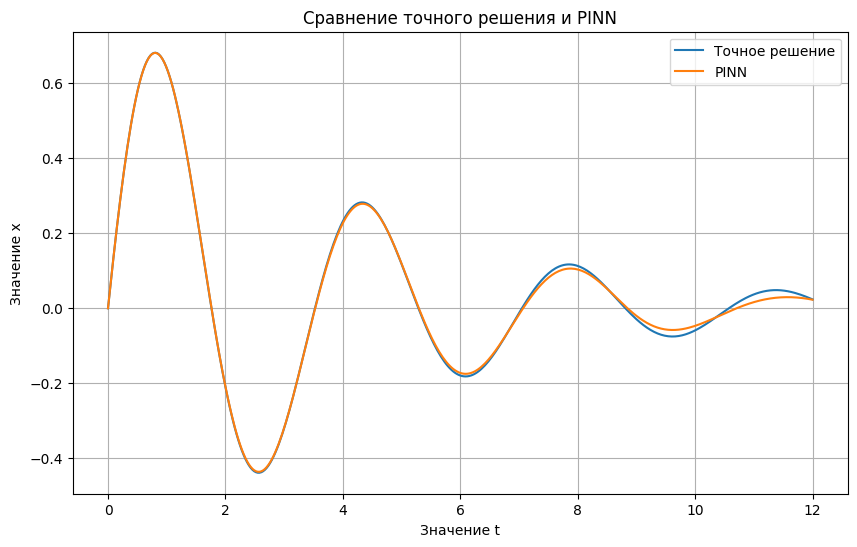

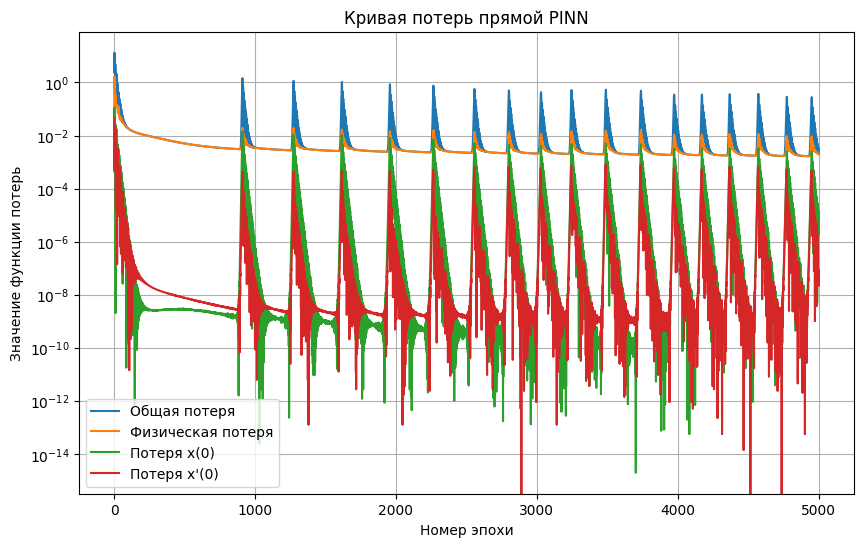

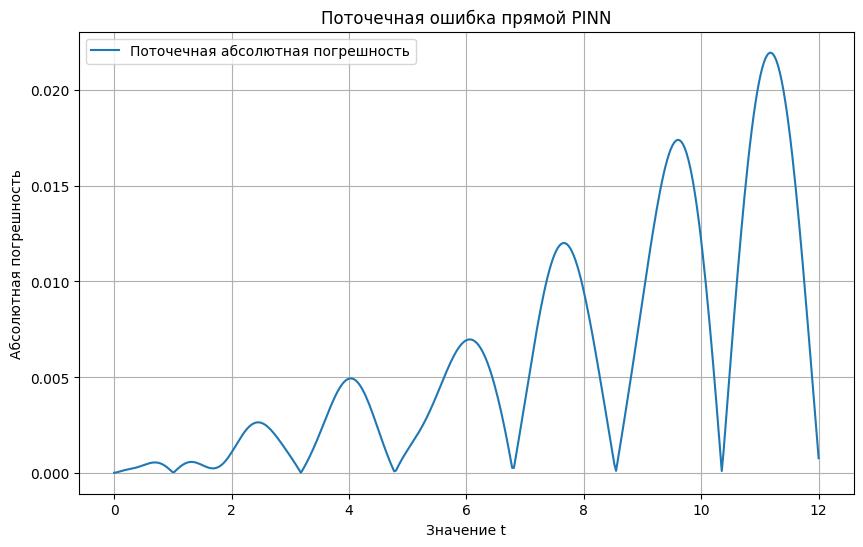

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(evaluation_time_values, evaluation_exact_values, label="Точное решение")
plt.plot(evaluation_time_values, evaluation_pinn_values, label="PINN")

plt.title("Сравнение точного решения и PINN")
plt.xlabel("Значение t")
plt.ylabel("Значение x")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

plt.plot(direct_epoch_history, direct_total_loss_history, label="Общая потеря")
plt.plot(direct_epoch_history, direct_physics_loss_history, label="Физическая потеря")
plt.plot(direct_epoch_history, direct_position_loss_history, label="Потеря x(0)")
plt.plot(direct_epoch_history, direct_velocity_loss_history, label="Потеря x'(0)")

plt.yscale("log")
plt.title("Кривая потерь прямой PINN")
plt.xlabel("Номер эпохи")
plt.ylabel("Значение функции потерь")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

plt.plot(
    evaluation_time_values,
    np.abs(evaluation_exact_values - evaluation_pinn_values),
    label="Поточечная абсолютная погрешность",
)

plt.title("Поточечная ошибка прямой PINN")
plt.xlabel("Значение t")
plt.ylabel("Абсолютная погрешность")
plt.legend()
plt.grid(True)
plt.show()

#### Физическая интерпретация

Полученное решение описывает слабозатухающие колебания около положения равновесия. Начальное смещение равно нулю, но начальная скорость $x'(0)=1.5$ выводит систему из равновесия

Амплитуда колебаний убывает по экспоненциальной огибающей $e^{-\delta t}$. Характерное время затухания равно $\tau=\dfrac{1}{\delta}=4$, то есть за 4 единицы времени огибающая уменьшается в $e$ раз. Частота затухающих колебаний равна $\omega\approx1.78255$, поэтому квазипериод равен $T_d=\dfrac{2\pi}{\omega}\approx3.52$

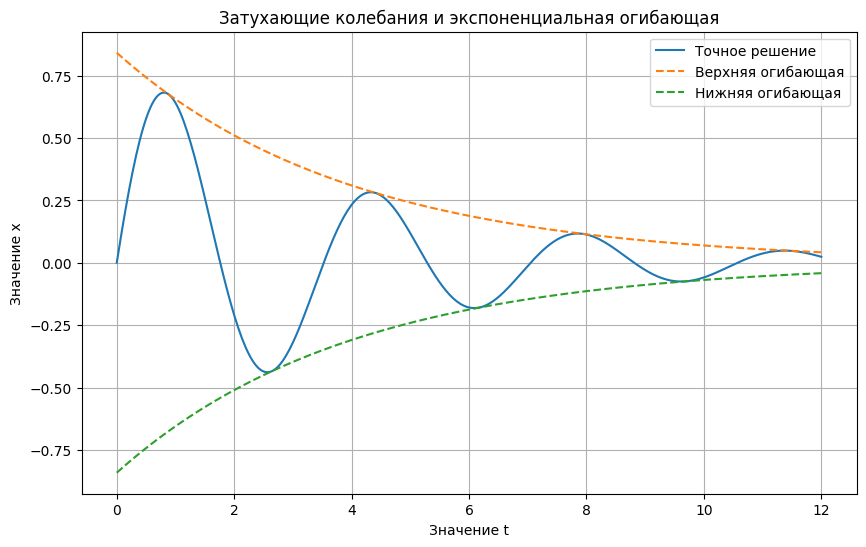

,Величина,Значение
0,Частота затухающих колебаний,1.782554e+00
1,Квазипериод,3.524821e+00
2,Время затухания,4.000000e+00


In [13]:
omega: float = float(np.sqrt(OMEGA_0 ** 2 - DELTA ** 2))
quasi_period: float = float(2.0 * np.pi / omega)
decay_time: float = float(1.0 / DELTA)
envelope_coefficient: float = float(INITIAL_VELOCITY / omega)
upper_envelope: NDArray[np.float64] = envelope_coefficient * np.exp(-DELTA * evaluation_time_values)
lower_envelope: NDArray[np.float64] = -upper_envelope

plt.figure(figsize=(10, 6))

plt.plot(evaluation_time_values, evaluation_exact_values, label="Точное решение")
plt.plot(evaluation_time_values, upper_envelope, linestyle="--", label="Верхняя огибающая")
plt.plot(evaluation_time_values, lower_envelope, linestyle="--", label="Нижняя огибающая")

plt.title("Затухающие колебания и экспоненциальная огибающая")
plt.xlabel("Значение t")
plt.ylabel("Значение x")
plt.legend()
plt.grid(True)
plt.show()

physical_values_table = pd.DataFrame(
    [
        ["Частота затухающих колебаний", omega],
        ["Квазипериод", quasi_period],
        ["Время затухания", decay_time],
    ],
    columns=["Величина", "Значение"],
)

physical_values_table

#### Зашумлённые данные и обратная задача

Для обратной задачи формируются экспериментальные данные. В равномерных точках $t_j$ к точному решению добавляется гауссовский шум:

$y_j=x_{exact}(t_j)+\varepsilon_j, \quad \varepsilon_j\sim\mathcal{N}(0, 0.05^2)$

В обратной задаче параметр $\omega_0$ считается известным, а параметр $\delta$ оценивается вместе с весами нейронной сети

In [14]:
noise_generator = np.random.default_rng(SEED)
noisy_time_values: NDArray[np.float64] = build_time_grid(
    TIME_START,
    TIME_END,
    DATA_POINT_COUNT,
)
noisy_exact_values: NDArray[np.float64] = exact_solution_array(noisy_time_values)
noise_values: NDArray[np.float64] = noise_generator.normal(
    loc=0.0,
    scale=NOISE_STANDARD_DEVIATION,
    size=DATA_POINT_COUNT,
).astype(np.float64)
noisy_values: NDArray[np.float64] = noisy_exact_values + noise_values

noisy_data_table = pd.DataFrame({
    "t": noisy_time_values,
    "Точное решение": noisy_exact_values,
    "Шум": noise_values,
    "Зашумлённое значение": noisy_values,
})

noisy_data_table.head(10)

,t,Точное решение,Шум,Зашумлённое значение
0,0.000000e+00,0.000000e+00,9.133783e-02,9.133783e-02
1,1.212121e-01,1.750219e-01,-1.539166e-01,2.110532e-02
2,2.424242e-01,3.316993e-01,4.790320e-02,3.796025e-01
3,3.636364e-01,4.639028e-01,3.481861e-03,4.673847e-01
4,4.848485e-01,5.669893e-01,6.591250e-02,6.329018e-01
5,6.060606e-01,6.379285e-01,1.928146e-02,6.572100e-01
6,7.272727e-01,6.753472e-01,9.136293e-02,7.667101e-01
7,8.484848e-01,6.794950e-01,1.587188e-03,6.810822e-01
8,9.696970e-01,6.521377e-01,-2.581147e-02,6.263262e-01
9,1.090909e+00,5.963865e-01,2.902425e-02,6.254108e-01


#### Обучение PINN для идентификации параметра

Параметр $\delta$ хранится как обучаемый параметр сети. Чтобы он оставался положительным, оптимизируется вспомогательная переменная $\rho$, а само значение вычисляется как $\delta=\operatorname{softplus}(\rho)$. Начальное значение задаётся равным 1.0, после чего оно должно сходиться к истинному значению 0.25

In [15]:
def inverse_softplus(value: float) -> float:
    return float(np.log(np.expm1(value)))


class InversePhysicsInformedNetwork(PhysicsInformedNetwork):
    def __init__(self) -> None:
        super().__init__()
        self.raw_delta = nn.Parameter(
            torch.tensor(
                inverse_softplus(INVERSE_DELTA_START),
                dtype=torch.float32,
                device=device,
            ),
        )

    def delta_value(self) -> torch.Tensor:
        return torch.nn.functional.softplus(self.raw_delta)


def calculate_inverse_loss(
    model: InversePhysicsInformedNetwork,
    collocation_time_tensor: torch.Tensor,
    data_time_tensor: torch.Tensor,
    data_value_tensor: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    estimated_delta: torch.Tensor = model.delta_value()
    residual_values: torch.Tensor = calculate_physics_residual(
        model,
        collocation_time_tensor,
        estimated_delta,
    )
    physics_loss: torch.Tensor = torch.mean(residual_values ** 2)
    position_loss, velocity_loss = calculate_initial_condition_loss(model)
    predicted_data_values: torch.Tensor = model(data_time_tensor)
    data_loss: torch.Tensor = torch.mean((predicted_data_values - data_value_tensor) ** 2)
    total_loss: torch.Tensor = (
        LAMBDA_DATA * data_loss
        + LAMBDA_INITIAL_POSITION * position_loss
        + LAMBDA_INITIAL_VELOCITY * velocity_loss
        + physics_loss
    )

    return total_loss, data_loss, position_loss, velocity_loss, physics_loss, estimated_delta


torch.manual_seed(SEED + 1)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED + 1)

inverse_collocation_time_tensor: torch.Tensor = build_time_tensor(
    direct_collocation_time_values,
    device,
)
noisy_time_tensor: torch.Tensor = build_time_tensor(noisy_time_values, device)
noisy_value_tensor: torch.Tensor = build_time_tensor(noisy_values, device)

inverse_model = InversePhysicsInformedNetwork().to(device)
inverse_pretrain_optimizer = torch.optim.Adam(inverse_model.parameters(), lr=LEARNING_RATE)
inverse_pretraining_loss_history: list[float] = []

for _ in range(INVERSE_PRETRAIN_EPOCH_COUNT):
    inverse_pretrain_optimizer.zero_grad()
    predicted_noisy_values: torch.Tensor = inverse_model(noisy_time_tensor)
    pretraining_loss: torch.Tensor = torch.mean((predicted_noisy_values - noisy_value_tensor) ** 2)
    pretraining_loss.backward()
    inverse_pretrain_optimizer.step()
    inverse_pretraining_loss_history.append(float(pretraining_loss.detach().cpu().item()))

inverse_optimizer = torch.optim.Adam(inverse_model.parameters(), lr=LEARNING_RATE)
inverse_epoch_history: list[int] = []
inverse_total_loss_history: list[float] = []
inverse_data_loss_history: list[float] = []
inverse_physics_loss_history: list[float] = []
estimated_delta_history: list[float] = []
inverse_log_rows: list[list[float]] = []

for epoch in range(1, INVERSE_EPOCH_COUNT + 1):
    inverse_optimizer.zero_grad()
    (
        total_loss,
        data_loss,
        position_loss,
        velocity_loss,
        physics_loss,
        estimated_delta,
    ) = calculate_inverse_loss(
        inverse_model,
        inverse_collocation_time_tensor,
        noisy_time_tensor,
        noisy_value_tensor,
    )
    total_loss.backward()
    inverse_optimizer.step()

    inverse_epoch_history.append(epoch)
    inverse_total_loss_history.append(float(total_loss.detach().cpu().item()))
    inverse_data_loss_history.append(float(data_loss.detach().cpu().item()))
    inverse_physics_loss_history.append(float(physics_loss.detach().cpu().item()))
    estimated_delta_history.append(float(inverse_model.delta_value().detach().cpu().item()))

    if epoch == 1 or epoch % LOG_STEP == 0 or epoch == INVERSE_EPOCH_COUNT:
        inverse_log_rows.append([
            float(epoch),
            float(total_loss.detach().cpu().item()),
            float(data_loss.detach().cpu().item()),
            float(physics_loss.detach().cpu().item()),
            float(inverse_model.delta_value().detach().cpu().item()),
        ])

inverse_training_log = pd.DataFrame(
    inverse_log_rows,
    columns=["Эпоха", "Общая потеря", "Потеря данных", "Физическая потеря", "Оценка delta"],
)

inverse_training_log

,Эпоха,Общая потеря,Потеря данных,Физическая потеря,Оценка delta
0,1.000000e+00,4.429549e+00,2.640772e-03,6.220045e-01,9.993680e-01
1,5.000000e+02,2.853141e-01,3.139762e-03,1.281148e-01,7.634385e-01
2,1.000000e+03,4.044450e-01,3.051381e-03,7.047367e-02,5.954230e-01
3,1.500000e+03,1.601847e-01,2.511606e-03,3.450906e-02,4.831212e-01
4,2.000000e+03,1.408887e-01,2.440288e-03,1.883827e-02,4.077398e-01
5,2.500000e+03,3.257589e-01,2.956110e-03,1.603036e-02,3.558351e-01
6,3.000000e+03,1.326759e-01,2.442740e-03,7.778029e-03,3.195793e-01
7,3.500000e+03,1.249072e-01,2.373765e-03,6.207676e-03,2.944501e-01
8,4.000000e+03,1.408711e-01,2.551805e-03,6.154813e-03,2.774394e-01
9,4.500000e+03,1.365267e-01,2.443771e-03,8.595689e-03,2.665823e-01


#### Графики обратной задачи

На первом графике показаны зашумлённые данные, истинное аналитическое решение и функция, восстановленная PINN. На втором графике показана сходимость оценки $\hat\delta$ к истинному значению $\delta=0.25$

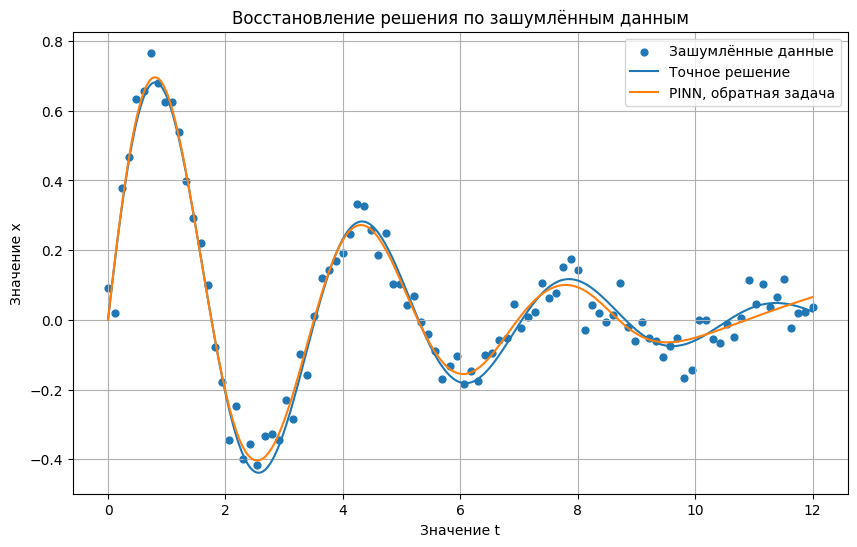

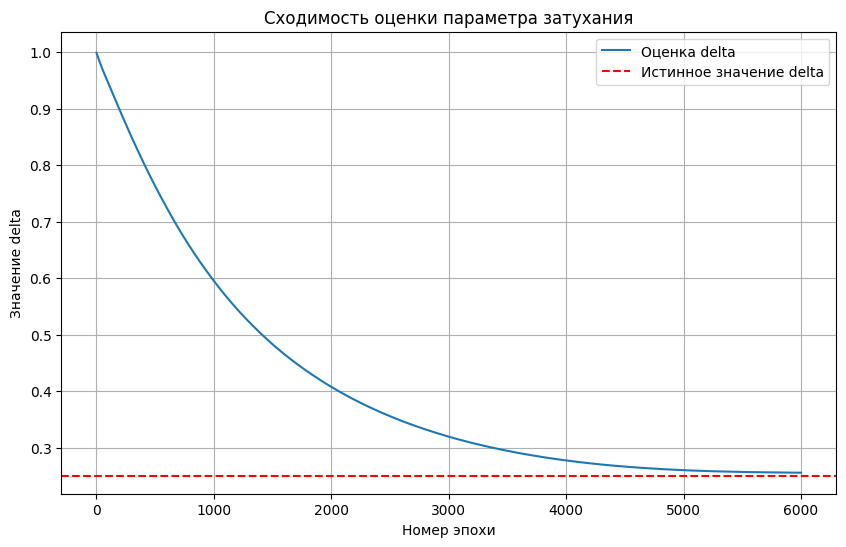

In [16]:
inverse_model.eval()
with torch.no_grad():
    inverse_fit_tensor: torch.Tensor = inverse_model(
        build_time_tensor(evaluation_time_values, device),
    )

inverse_fit_values: NDArray[np.float64] = tensor_to_array(inverse_fit_tensor)
final_estimated_delta: float = float(inverse_model.delta_value().detach().cpu().item())
delta_absolute_error: float = float(abs(final_estimated_delta - DELTA))
delta_relative_error: float = float(delta_absolute_error / DELTA)

plt.figure(figsize=(10, 6))

plt.scatter(noisy_time_values, noisy_values, s=24, label="Зашумлённые данные")
plt.plot(evaluation_time_values, evaluation_exact_values, label="Точное решение")
plt.plot(evaluation_time_values, inverse_fit_values, label="PINN, обратная задача")

plt.title("Восстановление решения по зашумлённым данным")
plt.xlabel("Значение t")
plt.ylabel("Значение x")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

plt.plot(inverse_epoch_history, estimated_delta_history, label="Оценка delta")
plt.axhline(DELTA, color="red", linestyle="--", label="Истинное значение delta")

plt.title("Сходимость оценки параметра затухания")
plt.xlabel("Номер эпохи")
plt.ylabel("Значение delta")
plt.legend()
plt.grid(True)
plt.show()

#### Таблица оценки параметра

В таблице сравниваются истинное значение параметра затухания и значение, найденное в обратной задаче. Абсолютная ошибка показывает отклонение оценки от параметра варианта 13, а относительная ошибка выражает это отклонение относительно истинного значения

In [17]:
parameter_table = pd.DataFrame(
    [
        [
            "delta",
            DELTA,
            final_estimated_delta,
            delta_absolute_error,
            delta_relative_error,
        ],
    ],
    columns=["Параметр", "Истинное значение", "Оценка PINN", "Абсолютная ошибка", "Относительная ошибка"],
)

parameter_table

,Параметр,Истинное значение,Оценка PINN,Абсолютная ошибка,Относительная ошибка
0,delta,2.500000e-01,2.557196e-01,5.719572e-03,2.287829e-02


#### Анализ результатов

В прямой задаче PINN воспроизводит колебательное решение на всём отрезке $[0, 12]$. Наибольшие отклонения возникают в областях, где решение быстро меняет знак, однако порядок максимальной абсолютной погрешности остаётся малым для выбранной сети

График функции потерь показывает, что физическая невязка уравнения уменьшается в процессе обучения. Начальные условия удерживаются весами $\lambda_0=\lambda_1=100$, поэтому в начале движения сеть согласуется с заданными $x(0)$ и $x'(0)$

В обратной задаче зашумлённые данные не мешают восстановить параметр затухания. Оценка $\hat\delta$ сходится из начального значения около 1.0 к окрестности истинного значения 0.25, что подтверждает применимость PINN для идентификации параметров дифференциального уравнения

#### Вывод

В ходе лабораторной работы была рассмотрена задача Коши для затухающего гармонического осциллятора $x''+2\delta x' + \omega_0^2x=0$ с параметрами варианта 13. Для этой задачи было получено аналитическое решение $x(t)=\dfrac{1.5}{\omega}e^{-0.25t}\sin(\omega t)$, где $\omega=\sqrt{1.8^2-0.25^2}$

Для прямой задачи была построена Physics-Informed Neural Network с четырьмя скрытыми слоями по 64 нейрона и функцией активации $\tanh$. Сеть обучалась с учётом начальных условий и физической невязки уравнения, а затем сравнивалась с аналитическим решением на контрольной сетке

Построенные графики показывают совпадение формы аналитического и приближённого решений: колебания происходят внутри экспоненциальной огибающей, а амплитуда убывает с характерным временем $\tau=4$. Таблица погрешностей показывает, что максимальная абсолютная ошибка прямой задачи остаётся на малом уровне

В обратной задаче по зашумлённым данным была восстановлена величина коэффициента затухания $\delta$. Полученная оценка близка к истинному значению $0.25$, поэтому метод PINN применим не только для аппроксимации решения, но и для идентификации параметров физической модели